In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [31]:
df = pd.read_csv(
    "../Data/Processed/hourly_demand_features.csv",
      parse_dates=["Unnamed: 0"]
)
print(df.shape)
print(df.columns.tolist())

(34896, 16)
['Unnamed: 0', 'total_demand', 'target', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'rolling_mean_24', 'rolling_std_24']


In [32]:
df = df.rename(columns={"Unnamed: 0": "datetime"})

In [33]:
df.head()

,datetime,total_demand,target,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,hour,day_of_week,is_weekend,hour_sin,hour_cos,rolling_mean_24,rolling_std_24
0,2011-01-08 00:00:00,86403.301624,72534.984171,111609.594412,130176.983542,141034.492592,85716.807571,85490.070525,69019.423424,0,5,1,0.000000,1.000000,120015.695552,29768.012259
1,2011-01-08 01:00:00,72534.984171,69325.030607,86403.301624,111609.594412,130176.983542,73297.911807,72602.273897,66344.627687,1,5,1,0.258819,0.965926,119983.906900,29820.431514
2,2011-01-08 02:00:00,69325.030607,68554.184257,72534.984171,86403.301624,111609.594412,70543.526944,69897.630958,65981.054883,2,5,1,0.500000,0.866025,119933.136219,29909.171077
3,2011-01-08 03:00:00,68554.184257,69033.522311,69325.030607,72534.984171,86403.301624,70242.037536,69467.257186,66576.533566,3,5,1,0.707107,0.707107,119862.809000,30032.821574
4,2011-01-08 04:00:00,69033.522311,76272.763924,68554.184257,69325.030607,72534.984171,68884.017033,69493.357908,64963.552675,4,5,1,0.866025,0.500000,119869.038386,30021.801334


In [34]:
check = df[["datetime", "total_demand", "target"]].head(10)

check

,datetime,total_demand,target
0,2011-01-08 00:00:00,86403.301624,72534.984171
1,2011-01-08 01:00:00,72534.984171,69325.030607
2,2011-01-08 02:00:00,69325.030607,68554.184257
3,2011-01-08 03:00:00,68554.184257,69033.522311
4,2011-01-08 04:00:00,69033.522311,76272.763924
5,2011-01-08 05:00:00,76272.763924,97049.021273
6,2011-01-08 06:00:00,97049.021273,110996.132753
7,2011-01-08 07:00:00,110996.132753,119102.366153
8,2011-01-08 08:00:00,119102.366153,139033.135912
9,2011-01-08 09:00:00,139033.135912,143329.185202


In [35]:
print(
    (df["target"].iloc[:-1].to_numpy()
     == df["total_demand"].iloc[1:].to_numpy()).all()
)

True


In [30]:
print(df.columns.tolist())
print(df.iloc[0])

['Unnamed: 0', 'total_demand', 'target', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'rolling_mean_24', 'rolling_std_24']
Unnamed: 0         2011-01-08 00:00:00
total_demand              86403.301624
target                    72534.984171
lag_1                    111609.594412
lag_2                    130176.983542
lag_3                    141034.492592
lag_24                    85716.807571
lag_48                    85490.070525
lag_168                   69019.423424
hour                                 0
day_of_week                          5
is_weekend                           1
hour_sin                           0.0
hour_cos                           1.0
rolling_mean_24          120015.695552
rolling_std_24            29768.012259
Name: 0, dtype: object


In [36]:
print(df["target"].isna().sum())

0


In [37]:
print(df.shape)
print(df.dtypes)
print()
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())
print()
print("Missing values:", df.isna().sum().sum())

(34896, 16)
datetime           datetime64[ns]
total_demand              float64
target                    float64
lag_1                     float64
lag_2                     float64
lag_3                     float64
lag_24                    float64
lag_48                    float64
lag_168                   float64
hour                        int64
day_of_week                 int64
is_weekend                  int64
hour_sin                  float64
hour_cos                  float64
rolling_mean_24           float64
rolling_std_24            float64
dtype: object

Start: 2011-01-08 00:00:00
End: 2014-12-31 23:00:00

Missing values: 0


In [38]:
df = df.sort_values("datetime").reset_index(drop=True)

print("Chronological:", df["datetime"].is_monotonic_increasing)
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())

Chronological: True
Start: 2011-01-08 00:00:00
End: 2014-12-31 23:00:00


In [39]:
print(df.shape)
print(df.dtypes)
print(df["target"].isna().sum())
print(df.isna().sum())

(34896, 16)
datetime           datetime64[ns]
total_demand              float64
target                    float64
lag_1                     float64
lag_2                     float64
lag_3                     float64
lag_24                    float64
lag_48                    float64
lag_168                   float64
hour                        int64
day_of_week                 int64
is_weekend                  int64
hour_sin                  float64
hour_cos                  float64
rolling_mean_24           float64
rolling_std_24            float64
dtype: object
0
datetime           0
total_demand       0
target             0
lag_1              0
lag_2              0
lag_3              0
lag_24             0
lag_48             0
lag_168            0
hour               0
day_of_week        0
is_weekend         0
hour_sin           0
hour_cos           0
rolling_mean_24    0
rolling_std_24     0
dtype: int64


In [40]:
target = "target"

feature_cols = [
    col for col in df.columns
    if col not in ["datetime", target]
]

X = df[feature_cols]
y = df[target]

print("Feature matrix:", X.shape)
print("Target:", y.shape)
print("\nFeatures:")
print(feature_cols)

Feature matrix: (34896, 14)
Target: (34896,)

Features:
['total_demand', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'rolling_mean_24', 'rolling_std_24']


In [41]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

In [42]:
print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

print("\nTraining features:", X_train.shape)
print("Test features:", X_test.shape)

Training observations: 27916
Test observations: 6980

Training features: (27916, 14)
Test features: (6980, 14)


In [43]:
train_dates = df["datetime"].iloc[:split_index]
test_dates = df["datetime"].iloc[split_index:]

print("Training period:")
print(train_dates.min(), "→", train_dates.max())

print("\nTest period:")
print(test_dates.min(), "→", test_dates.max())

Training period:
2011-01-08 00:00:00 → 2014-03-16 03:00:00

Test period:
2014-03-16 04:00:00 → 2014-12-31 23:00:00


In [44]:
print(
    "\nTest starts after training:",
    test_dates.min() > train_dates.max()
)


Test starts after training: True


In [45]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [46]:
baseline_xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [47]:
baseline_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [48]:
baseline_pred = baseline_xgb.predict(X_test)

In [49]:
baseline_mae = mean_absolute_error(y_test, baseline_pred)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)

print("Baseline XGBoost")
print("----------------")
print(f"MAE:  {baseline_mae:,.2f}")
print(f"RMSE: {baseline_rmse:,.2f}")

Baseline XGBoost
----------------
MAE:  4,606.74
RMSE: 6,790.25


In [50]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

In [51]:
for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_train),
    start=1
):
    print(f"Fold {fold}")
    print(f"  Training observations:   {len(train_idx):,}")
    print(f"  Validation observations: {len(val_idx):,}")
    print(
        f"  Training range:   "
        f"{train_idx[0]:,} → {train_idx[-1]:,}"
    )
    print(
        f"  Validation range: "
        f"{val_idx[0]:,} → {val_idx[-1]:,}"
    )
    print()

Fold 1
  Training observations:   4,656
  Validation observations: 4,652
  Training range:   0 → 4,655
  Validation range: 4,656 → 9,307

Fold 2
  Training observations:   9,308
  Validation observations: 4,652
  Training range:   0 → 9,307
  Validation range: 9,308 → 13,959

Fold 3
  Training observations:   13,960
  Validation observations: 4,652
  Training range:   0 → 13,959
  Validation range: 13,960 → 18,611

Fold 4
  Training observations:   18,612
  Validation observations: 4,652
  Training range:   0 → 18,611
  Validation range: 18,612 → 23,263

Fold 5
  Training observations:   23,264
  Validation observations: 4,652
  Training range:   0 → 23,263
  Validation range: 23,264 → 27,915



In [52]:
from sklearn.model_selection import RandomizedSearchCV

In [53]:
param_distributions = {
    "n_estimators": [100, 200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.3, 0.5]
}

In [54]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [55]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,30
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [56]:
print("Best parameters:")
print(random_search.best_params_)

Best parameters:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.7}


In [57]:
print("Best CV MAE:")
print(-random_search.best_score_)

Best CV MAE:
9938.070205898379


In [58]:
best_xgb = random_search.best_estimator_

In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

tuned_pred = best_xgb.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))

print("Tuned XGBoost")
print("-------------")
print(f"MAE:  {tuned_mae:,.2f}")
print(f"RMSE: {tuned_rmse:,.2f}")

Tuned XGBoost
-------------
MAE:  5,154.45
RMSE: 7,270.61


In [60]:
from sklearn.metrics import mean_absolute_error

fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    tscv.split(X_train),
    start=1
):
    model = XGBRegressor(
        **random_search.best_params_,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train.iloc[train_idx],
        y_train.iloc[train_idx]
    )

    val_pred = model.predict(X_train.iloc[val_idx])

    fold_mae = mean_absolute_error(
        y_train.iloc[val_idx],
        val_pred
    )

    fold_results.append({
        "fold": fold,
        "mae": fold_mae,
        "validation_start": df["datetime"].iloc[
            split_index - len(X_train) + val_idx[0]
        ],
        "validation_end": df["datetime"].iloc[
            split_index - len(X_train) + val_idx[-1]
        ]
    })

fold_results_df = pd.DataFrame(fold_results)

fold_results_df

,fold,mae,validation_start,validation_end
0,1,7154.959580,2011-07-21 00:00:00,2012-01-30 19:00:00
1,2,25469.829228,2012-01-30 20:00:00,2012-08-11 15:00:00
2,3,5650.827589,2012-08-11 16:00:00,2013-02-21 11:00:00
3,4,6077.137996,2013-02-21 12:00:00,2013-09-03 07:00:00
4,5,5033.982229,2013-09-03 08:00:00,2014-03-16 03:00:00


In [61]:
fold_2_train_idx, fold_2_val_idx = list(tscv.split(X_train))[1]

fold_2_train_y = y_train.iloc[fold_2_train_idx]
fold_2_val_y = y_train.iloc[fold_2_val_idx]

print("Fold 2 training target:")
print(fold_2_train_y.describe())

print("\nFold 2 validation target:")
print(fold_2_val_y.describe())

Fold 2 training target:
count      9308.000000
mean     127746.990211
std       39474.661811
min       51641.138616
25%       95272.741708
50%      134043.288633
75%      150852.876585
max      266838.717263
Name: target, dtype: float64

Fold 2 validation target:
count      4652.000000
mean     214582.856918
std       84226.915206
min        4287.094195
25%      135262.264851
50%      220426.768332
75%      260753.915035
max      448148.758471
Name: target, dtype: float64


In [62]:
fold_2_model = XGBRegressor(
    **random_search.best_params_,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

fold_2_model.fit(
    X_train.iloc[fold_2_train_idx],
    y_train.iloc[fold_2_train_idx]
)

fold_2_pred = fold_2_model.predict(
    X_train.iloc[fold_2_val_idx]
)

fold_2_errors = pd.DataFrame({
    "actual": y_train.iloc[fold_2_val_idx].values,
    "predicted": fold_2_pred
})

fold_2_errors["absolute_error"] = (
    abs(fold_2_errors["actual"] - fold_2_errors["predicted"])
)

print(fold_2_errors["absolute_error"].describe())

count      4652.000000
mean      25469.829228
std       38925.895157
min          13.719888
25%        2200.955729
50%        5777.230032
75%       32387.983932
max      196807.227221
Name: absolute_error, dtype: float64


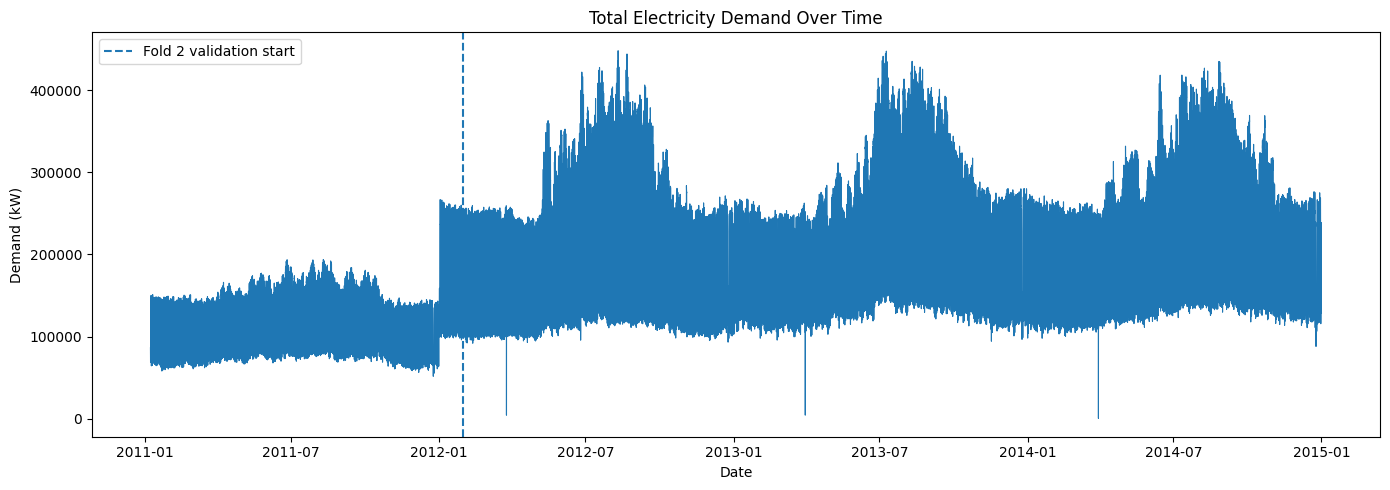

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    df["datetime"],
    df["total_demand"],
    linewidth=0.8
)

plt.axvline(
    pd.Timestamp("2012-01-30 20:00"),
    linestyle="--",
    label="Fold 2 validation start"
)

plt.title("Total Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand (kW)")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
df.nlargest(
    10,
    "total_demand"
)[[
    "datetime",
    "total_demand",
    "target"
]]

,datetime,total_demand,target
13936,2012-08-10 16:00:00,448148.758471,444825.927319
21929,2013-07-09 17:00:00,447604.465512,437710.697942
13937,2012-08-10 17:00:00,444825.927319,437095.328526
21904,2013-07-08 16:00:00,444451.095364,438483.404666
21927,2013-07-09 15:00:00,444208.313069,443755.398834
14201,2012-08-21 17:00:00,444167.821544,436809.397215
14200,2012-08-21 16:00:00,443765.212860,444167.821544
21928,2013-07-09 16:00:00,443755.398834,447604.465512
14199,2012-08-21 15:00:00,443593.012571,443765.212860
21926,2013-07-09 14:00:00,443404.651813,444208.313069


In [65]:
df.nsmallest(
    10,
    "total_demand"
)[[
    "datetime",
    "total_demand",
    "target"
]]

,datetime,total_demand,target
28249,2014-03-30 01:00:00,454.479877,125376.540879
10609,2012-03-25 01:00:00,4287.094195,115938.933907
19513,2013-03-31 01:00:00,4369.792942,124604.018041
8428,2011-12-25 04:00:00,51641.138616,51880.246453
8429,2011-12-25 05:00:00,51880.246453,53453.678885
8427,2011-12-25 03:00:00,52513.829222,51641.138616
8426,2011-12-25 02:00:00,53240.703166,52513.829222
8430,2011-12-25 06:00:00,53453.678885,58428.856939
8452,2011-12-26 04:00:00,55386.344116,64473.678310
8451,2011-12-26 03:00:00,55757.611948,55386.344116


In [66]:
monthly_demand = (
    df.set_index("datetime")["total_demand"]
    .resample("ME")
    .mean()
)

monthly_demand.head()

datetime
2011-01-31    115284.103978
2011-02-28    115275.402912
2011-03-31    115298.645312
2011-04-30    123905.071921
2011-05-31    129100.946017
Freq: ME, Name: total_demand, dtype: float64

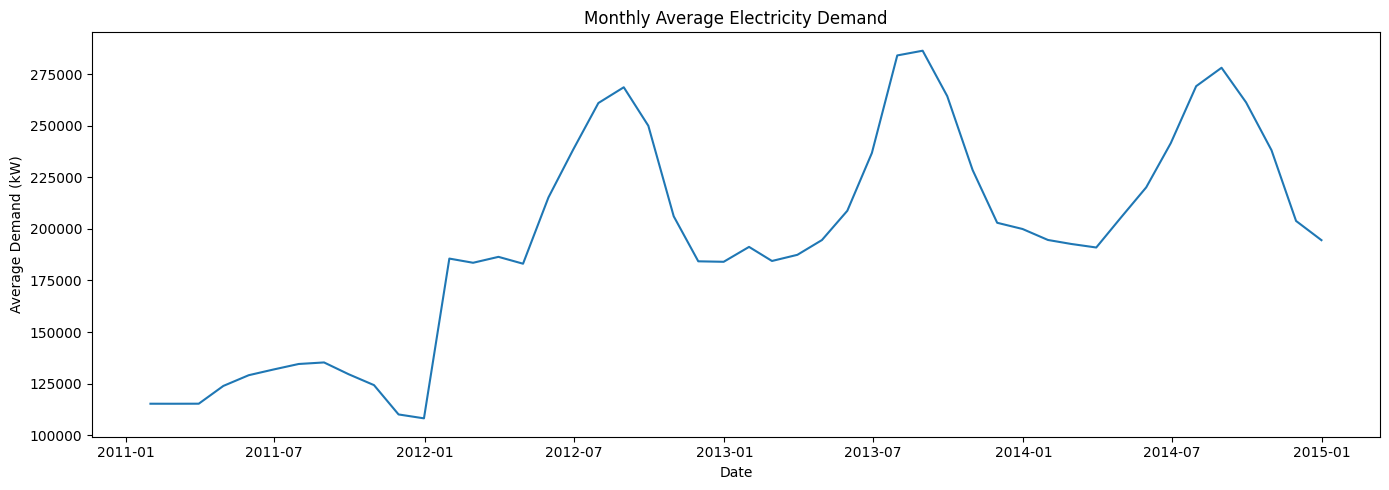

In [67]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values
)

plt.title("Monthly Average Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Average Demand (kW)")
plt.tight_layout()
plt.show()

In [68]:
annual_demand = (
    df.set_index("datetime")["total_demand"]
    .resample("YE")
    .mean()
)

print(annual_demand)

datetime
2011-12-31    122920.292553
2012-12-31    212317.434423
2013-12-31    222736.769017
2014-12-31    224410.873185
Freq: YE-DEC, Name: total_demand, dtype: float64


In [69]:
print(
    df[["total_demand", "target"]].corr()
)

              total_demand   target
total_demand       1.00000  0.96804
target             0.96804  1.00000


In [70]:
naive_pred = X_test["total_demand"]

naive_mae = mean_absolute_error(
    y_test,
    naive_pred
)

naive_rmse = np.sqrt(
    mean_squared_error(y_test, naive_pred)
)

print("Naive persistence baseline")
print("-------------------------")
print(f"MAE:  {naive_mae:,.2f}")
print(f"RMSE: {naive_rmse:,.2f}")

Naive persistence baseline
-------------------------
MAE:  16,475.72
RMSE: 24,779.80


In [71]:
hourly_change = (
    df["target"] - df["total_demand"]
)

print(hourly_change.describe())

count     34896.000000
mean          1.083531
std       21202.327577
min     -150122.431440
25%       -6590.693960
50%         573.258281
75%        8757.842097
max      128348.122589
dtype: float64


In [72]:
print(
    "Mean absolute hourly change:",
    hourly_change.abs().mean()
)

print(
    "Median absolute hourly change:",
    hourly_change.abs().median()
)

Mean absolute hourly change: 13681.28805074424
Median absolute hourly change: 7697.751177145867


In [73]:
correlations = (
    df[
        [
            "target",
            "total_demand",
            "lag_1",
            "lag_2",
            "lag_3",
            "lag_24",
            "lag_48",
            "lag_168",
            "rolling_mean_24"
        ]
    ]
    .corr()["target"]
    .sort_values(ascending=False)
)

print(correlations)

target             1.000000
total_demand       0.968040
lag_24             0.958670
lag_48             0.952002
lag_168            0.942534
lag_1              0.889717
lag_2              0.780575
lag_3              0.650587
rolling_mean_24    0.621304
Name: target, dtype: float64


In [74]:
test_results = pd.DataFrame({
    "datetime": df["datetime"].iloc[split_index:].values,
    "actual": y_test.values,
    "predicted": baseline_pred
})

test_results["absolute_error"] = (
    abs(
        test_results["actual"]
        - test_results["predicted"]
    )
)

test_results["hour"] = test_results["datetime"].dt.hour

hourly_error = (
    test_results
    .groupby("hour")["absolute_error"]
    .mean()
)

print(hourly_error)

hour
0     5411.798579
1     2457.575772
2     2188.970125
3     2266.409562
4     2932.326619
5     2152.344448
6     2384.756967
7     2942.336624
8     6322.846676
9     8155.780981
10    6132.324188
11    5151.778081
12    5089.793136
13    4104.905806
14    4049.563255
15    4138.044588
16    4551.315922
17    4815.652270
18    5149.912358
19    4784.353755
20    5631.482840
21    7720.070585
22    7344.608644
23    4661.878174
Name: absolute_error, dtype: float64


In [75]:
mae_improvement = (
    (naive_mae - baseline_mae)
    / naive_mae
    * 100
)

rmse_improvement = (
    (naive_rmse - baseline_rmse)
    / naive_rmse
    * 100
)

print(f"MAE improvement over naive:  {mae_improvement:.2f}%")
print(f"RMSE improvement over naive: {rmse_improvement:.2f}%")

MAE improvement over naive:  72.04%
RMSE improvement over naive: 72.60%


In [76]:
from pathlib import Path

models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

print(f"Models directory: {models_dir.resolve()}")

Models directory: C:\Users\Administrator\Desktop\Energy-Project\models


In [77]:
import joblib

final_model_path = models_dir / "xgboost_energy_forecaster.joblib"

joblib.dump(baseline_xgb, final_model_path)

print(f"Model saved to: {final_model_path}")
print(f"File size: {final_model_path.stat().st_size:,} bytes")

Model saved to: ..\models\xgboost_energy_forecaster.joblib
File size: 439,465 bytes


In [78]:
import json

metadata = {
    "model_type": "XGBRegressor",
    "model_file": "xgboost_energy_forecaster.joblib",
    "target": "target",
    "forecast_horizon": "1 hour",
    
    "features": feature_cols,
    "n_features": len(feature_cols),
    
    "metrics": {
        "mae": float(baseline_mae),
        "rmse": float(baseline_rmse),
        "naive_mae": float(naive_mae),
        "naive_rmse": float(naive_rmse),
        "mae_improvement_over_naive_percent": float(mae_improvement),
        "rmse_improvement_over_naive_percent": float(rmse_improvement)
    },
    
    "data_split": {
        "method": "chronological",
        "train_ratio": 0.8,
        "test_ratio": 0.2
    },
    
    "cross_validation": {
        "method": "TimeSeriesSplit",
        "n_splits": 5
    },
    
    "random_state": 42
}

metadata_path = models_dir / "model_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"Metadata saved to: {metadata_path}")

Metadata saved to: ..\models\model_metadata.json


In [79]:
loaded_model = joblib.load(final_model_path)

loaded_predictions = loaded_model.predict(X_test)

predictions_match = (loaded_predictions == baseline_pred).all()

print(f"Predictions match: {predictions_match}")

Predictions match: True


In [80]:
import numpy as np

predictions_match = np.allclose(
    loaded_predictions,
    baseline_pred
)

print(f"Predictions match: {predictions_match}")

Predictions match: True


In [81]:
with open(metadata_path, "r") as f:
    saved_metadata = json.load(f)

print(saved_metadata)

{'model_type': 'XGBRegressor', 'model_file': 'xgboost_energy_forecaster.joblib', 'target': 'target', 'forecast_horizon': '1 hour', 'features': ['total_demand', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'hour', 'day_of_week', 'is_weekend', 'hour_sin', 'hour_cos', 'rolling_mean_24', 'rolling_std_24'], 'n_features': 14, 'metrics': {'mae': 4606.74165656537, 'rmse': 6790.251859292796, 'naive_mae': 16475.71716786346, 'naive_rmse': 24779.796900802456, 'mae_improvement_over_naive_percent': 72.03920406238217, 'rmse_improvement_over_naive_percent': 72.59762908277548}, 'data_split': {'method': 'chronological', 'train_ratio': 0.8, 'test_ratio': 0.2}, 'cross_validation': {'method': 'TimeSeriesSplit', 'n_splits': 5}, 'random_state': 42}


In [82]:
print("Current baseline metrics:")
print(f"MAE:  {baseline_mae:.6f}")
print(f"RMSE: {baseline_rmse:.6f}")

print("\nCurrent baseline predictions:")
print(baseline_pred[:5])

print("\nModel parameters:")
print(baseline_xgb.get_params())

Current baseline metrics:
MAE:  4606.741657
RMSE: 6790.251859

Current baseline predictions:
[112523.47 126761.38 144092.61 148618.38 187241.55]

Model parameters:
{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 100, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'su

In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

check_mae = mean_absolute_error(y_test, baseline_pred)
check_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Recalculated MAE:  {check_mae:.6f}")
print(f"Recalculated RMSE: {check_rmse:.6f}")

Recalculated MAE:  4606.741657
Recalculated RMSE: 6790.251859


In [84]:
# Check timestamp spacing
time_diffs = df["datetime"].diff().dropna()

print("Most common time differences:")
print(time_diffs.value_counts().head())

expected_interval = pd.Timedelta(hours=1)

print("\nAre all intervals exactly 1 hour?")
print((time_diffs == expected_interval).all())

Most common time differences:
datetime
0 days 01:00:00    34895
Name: count, dtype: int64

Are all intervals exactly 1 hour?
True


In [88]:
# Inspect the first 30 rows of the relevant columns
df[
    [
        "datetime",
        "total_demand",
        "rolling_mean_24",
        "rolling_std_24"
    ]
].head(10)

,datetime,total_demand,rolling_mean_24,rolling_std_24
0,2011-01-08 00:00:00,86403.301624,120015.695552,29768.012259
1,2011-01-08 01:00:00,72534.984171,119983.906900,29820.431514
2,2011-01-08 02:00:00,69325.030607,119933.136219,29909.171077
3,2011-01-08 03:00:00,68554.184257,119862.809000,30032.821574
4,2011-01-08 04:00:00,69033.522311,119869.038386,30021.801334
5,2011-01-08 05:00:00,76272.763924,119820.839039,30093.741831
6,2011-01-08 06:00:00,97049.021273,119732.284139,30160.192126
7,2011-01-08 07:00:00,110996.132753,119640.854858,30184.202089
8,2011-01-08 08:00:00,119102.366153,119563.651334,30183.063611
9,2011-01-08 09:00:00,139033.135912,119637.769894,30230.540876


In [87]:
# Check whether rolling features are based only on current/past observations

rolling_check = df[
    [
        "total_demand",
        "rolling_mean_24",
        "rolling_std_24"
    ]
].copy()

print(rolling_check.head(10))

    total_demand  rolling_mean_24  rolling_std_24
0   86403.301624    120015.695552    29768.012259
1   72534.984171    119983.906900    29820.431514
2   69325.030607    119933.136219    29909.171077
3   68554.184257    119862.809000    30032.821574
4   69033.522311    119869.038386    30021.801334
5   76272.763924    119820.839039    30093.741831
6   97049.021273    119732.284139    30160.192126
7  110996.132753    119640.854858    30184.202089
8  119102.366153    119563.651334    30183.063611
9  139033.135912    119637.769894    30230.540876


In [89]:
df["rolling_mean_24"] = (
    df["total_demand"]
    .rolling(window=24)
    .mean()
)

In [90]:
df["rolling_std_24"] = (
    df["total_demand"]
    .rolling(window=24)
    .std()
)